In [1]:
import numpy as np
import read_bs
import matplotlib.pyplot as plt
import corner
from matplotlib import colors

### Reading bispectrum data

In [2]:

# paths to the bs data
path_to_bs_data = "/home/leon/Documents/data/ska_ch_data/deriv/bs_data_out_new"
paths_params = [ "Lightcone_HII_EFF_FACTOR_400_Samples_Plus", "Lightcone_HII_EFF_FACTOR_400_Samples_Minus","Lightcone_ION_Tvir_MIN_400_Samples_Plus",
                "Lightcone_ION_Tvir_MIN_400_Samples_Minus", "Lightcone_R_BUBBLE_MAX_400_Samples_Plus", "Lightcone_R_BUBBLE_MAX_400_Samples_Minus"]
paths = [path_to_bs_data + "/" + path for path in paths_params]
bs_data_cov_path_ska_AA_star_1000 = "/home/leon/Documents/data/ska_ch_data/ska_AA_star_1000/bs_data_out_new"
bs_data_cov_path_ska_AA_star_100 = "/home/leon/Documents/data/ska_ch_data/ska_AA_star_100/bs_data_out_new"
bs_data_cov_path_ska_AA4_1000 = "/home/leon/Documents/data/ska_ch_data/ska_AA4_1000/bs_data_out_new"


In [3]:
# arrays to hold the bispectrum data and related parameters
num_k1_values = 40  # number of k1 bins
num_samples = 399   # number of realizations
n_params = 3        # number of model parameters
params = ['ION_Tvir_MIN','R_BUBBLE_MAX','HII_EFF_FACTOR']  # parameter names

# squeezed limit bispectrum data for each parameter variation and fiducial runs
data_bs_squeezed = np.zeros((6, num_samples, num_k1_values))
data_bs_fidu_ska_AA_star_1000_squeezed = np.zeros((num_samples, num_k1_values))
data_bs_fidu_ska_AA_star_100_squeezed = np.zeros((num_samples, num_k1_values))
data_bs_fidu_ska_AA4_1000_squeezed = np.zeros((num_samples, num_k1_values))

# Step sizes for finite difference derivatives of each parameter
delta_params = [
    10,  # HII_EFF_FACTOR
    10,  # R_BUBBLE_MAX
    pow(10, 4.740362689494244) - pow(10, 4.653212513775344)  # Tvir_MIN 
    ] 

In [4]:
# Reading bispectrum data for squeezed limit for all realizations

# loop over all parameters
for i in range(len(paths)):
    # loop over all realizations
    for j in range(num_samples):
        # Auto_BS_Data object for the current parameter and realization
        bs_data = read_bs.Auto_BS_Data("{}/realization_{}".format(paths[i], int(j)))
        data_bs_squeezed[i, j, :] = bs_data.get_squeezed_limit()

# loop over all realizations for SKA AA star 1000 fiducial run
for j in range(num_samples):
    bs_data = read_bs.Auto_BS_Data("{}/realization_{}".format(bs_data_cov_path_ska_AA_star_1000, int(j)))
    data_bs_fidu_ska_AA_star_1000_squeezed[j, :] = bs_data.get_squeezed_limit()

# loop over all realizations for SKA AA star 100 fiducial run
for j in range(num_samples):
    bs_data = read_bs.Auto_BS_Data("{}/realization_{}".format(bs_data_cov_path_ska_AA_star_100, int(j)))
    data_bs_fidu_ska_AA_star_100_squeezed[j, :] = bs_data.get_squeezed_limit()

# loop over all realizations for SKA AA4 1000 fiducial run
for j in range(num_samples):
    bs_data = read_bs.Auto_BS_Data("{}/realization_{}".format(bs_data_cov_path_ska_AA4_1000, int(j)))
    data_bs_fidu_ska_AA4_1000_squeezed[j, :] = bs_data.get_squeezed_limit()

### Finding the derivatives

In [5]:
# finding derivatives for the bispectrum data for all unique triangles
der_bs_HII_EFF = data_bs_squeezed[0, :, 4:] - data_bs_squeezed[1, :, 4:] / delta_params[0]
der_bs_Tvir_MIN = data_bs_squeezed[2, :, 4:] - data_bs_squeezed[3, :, 4:] / delta_params[2]
der_bs_R_BUBBLE_MAX = data_bs_squeezed[4, :, 4:] - data_bs_squeezed[5, :, 4:] / delta_params[1]


### Estimating the Covariance

In [6]:
# estimating the standard deviation for each k-bin from the fiducial runs
sigma_sq_ska_AA_star_1000 = np.std(data_bs_fidu_ska_AA_star_1000_squeezed[:, 4:], axis=0)
sigma_sq_ska_AA_star_100 = np.std(data_bs_fidu_ska_AA_star_100_squeezed[:, 4:], axis=0)
sigma_sq_ska_AA4_1000 = np.std(data_bs_fidu_ska_AA4_1000_squeezed[:, 4:], axis=0)

In [7]:
# whiting step
# SKA AA star 1000
white_data_bs_fidu_ska_AA_star_1000 = data_bs_fidu_ska_AA_star_1000_squeezed[:, 4:] / sigma_sq_ska_AA_star_1000
# Whitening the derivatives
white_der_bs_HII_EFF_ska_AA_star_1000 = der_bs_HII_EFF / sigma_sq_ska_AA_star_1000
white_der_bs_Tvir_MIN_ska_AA_star_1000 = der_bs_Tvir_MIN / sigma_sq_ska_AA_star_1000
white_der_bs_R_BUBBLE_MAX_ska_AA_star_1000 = der_bs_R_BUBBLE_MAX / sigma_sq_ska_AA_star_1000

# SKA AA star 100
white_data_bs_fidu_ska_AA_star_100 = data_bs_fidu_ska_AA_star_100_squeezed[:, 4:] / sigma_sq_ska_AA_star_100
# Whitening the derivatives
white_der_bs_HII_EFF_ska_AA_star_100 = der_bs_HII_EFF / sigma_sq_ska_AA_star_100
white_der_bs_Tvir_MIN_ska_AA_star_100 = der_bs_Tvir_MIN / sigma_sq_ska_AA_star_100
white_der_bs_R_BUBBLE_MAX_ska_AA_star_100 = der_bs_R_BUBBLE_MAX / sigma_sq_ska_AA_star_100

# SKA AA4 1000
white_data_bs_fidu_ska_AA4_1000 = data_bs_fidu_ska_AA4_1000_squeezed[:, 4:] / sigma_sq_ska_AA4_1000
# Whitening the derivatives
white_der_bs_HII_EFF_ska_AA4_1000 = der_bs_HII_EFF / sigma_sq_ska_AA4_1000
white_der_bs_Tvir_MIN_ska_AA4_1000 = der_bs_Tvir_MIN / sigma_sq_ska_AA4_1000
white_der_bs_R_BUBBLE_MAX_ska_AA4_1000 = der_bs_R_BUBBLE_MAX / sigma_sq_ska_AA4_1000

# rearranging the derivatives into a single array 
deriv_field_ska_AA_star_1000 = np.zeros((6, np.shape(white_der_bs_HII_EFF_ska_AA_star_1000)[0], np.shape(white_der_bs_HII_EFF_ska_AA_star_1000)[1]))
deriv_field_ska_AA_star_100 = np.zeros((6, np.shape(white_der_bs_HII_EFF_ska_AA_star_100)[0], np.shape(white_der_bs_HII_EFF_ska_AA_star_100)[1]))
deriv_field_ska_AA4_1000 = np.zeros((6, np.shape(white_der_bs_HII_EFF_ska_AA4_1000)[0], np.shape(white_der_bs_HII_EFF_ska_AA4_1000)[1]))

# SKA AA4 1000
deriv_field_ska_AA4_1000[0] = white_der_bs_Tvir_MIN_ska_AA4_1000
deriv_field_ska_AA4_1000[1] = white_der_bs_R_BUBBLE_MAX_ska_AA4_1000
deriv_field_ska_AA4_1000[2] = white_der_bs_HII_EFF_ska_AA4_1000
# SKA AA star 1000
deriv_field_ska_AA_star_1000[0] = white_der_bs_Tvir_MIN_ska_AA_star_1000
deriv_field_ska_AA_star_1000[1] = white_der_bs_R_BUBBLE_MAX_ska_AA_star_1000
deriv_field_ska_AA_star_1000[2] = white_der_bs_HII_EFF_ska_AA_star_1000
# SKA AA star 100
deriv_field_ska_AA_star_100[0] = white_der_bs_Tvir_MIN_ska_AA_star_100
deriv_field_ska_AA_star_100[1] = white_der_bs_R_BUBBLE_MAX_ska_AA_star_100
deriv_field_ska_AA_star_100[2] = white_der_bs_HII_EFF_ska_AA_star_100

In [8]:
# computing the covariance matrices
covariance_ska_AA_star_1000 = np.cov(white_data_bs_fidu_ska_AA_star_1000, rowvar=False)
covariance_ska_AA_star_100 = np.cov(white_data_bs_fidu_ska_AA_star_100, rowvar=False)
covariance_ska_AA4_1000 = np.cov(white_data_bs_fidu_ska_AA4_1000, rowvar=False)


In [9]:
print(f'log Condition number of the covariance matrix SKA AA* 1000: {np.log10(np.linalg.cond(covariance_ska_AA_star_1000)):.2f} (should be <= 7).')
print(f'log Condition number of the covariance matrix SKA AA* 100: {np.log10(np.linalg.cond(covariance_ska_AA_star_100)):.2f} (should be <= 7).')
print(f'log Condition number of the covariance matrix SKA AA4 1000: {np.log10(np.linalg.cond(covariance_ska_AA4_1000)):.2f} (should be <= 7).')


log Condition number of the covariance matrix SKA AA* 1000: 0.48 (should be <= 7).
log Condition number of the covariance matrix SKA AA* 100: 0.48 (should be <= 7).
log Condition number of the covariance matrix SKA AA4 1000: 0.55 (should be <= 7).


### Estimating the Fisher matrix

In [10]:
# Calculating the Fisher matrix
samples = np.arange(5, num_samples+5, 5)
# array to hold the Fisher matrices
BS_Fisher_SKA_AA_star_1000 = np.zeros((samples.shape[0], n_params, n_params))
BS_Fisher_SKA_AA_star_100 = np.zeros((samples.shape[0], n_params, n_params))
BS_Fisher_SKA_AA4_1000 = np.zeros((samples.shape[0], n_params, n_params))
# array to hold the inverse Fisher matrices
BS_Fisher_Inv_SKA_AA_star_1000 =  np.zeros((samples.shape[0], n_params, n_params))
BS_Fisher_Inv_SKA_AA_star_100 =  np.zeros((samples.shape[0], n_params, n_params))
BS_Fisher_Inv_SKA_AA4_1000 =  np.zeros((samples.shape[0], n_params, n_params))

# loop over different sample sizes
for k, sample in enumerate(samples):
    deriv_ska_AA_star_1000_sample = np.mean(deriv_field_ska_AA_star_1000[:, :sample, :], axis=1)
    deriv_ska_AA_star_100_sample = np.mean(deriv_field_ska_AA_star_100[:, :sample, :], axis=1)
    deriv_ska_AA4_1000_sample = np.mean(deriv_field_ska_AA4_1000[:, :sample, :], axis=1)

    for i in range(n_params):
        for j in range(n_params):
            # computing the Fisher matrix elements
            BS_Fisher_SKA_AA_star_1000[k, i, j] = np.dot(deriv_ska_AA_star_1000_sample[i], np.dot(np.linalg.inv(covariance_ska_AA_star_1000), deriv_ska_AA_star_1000_sample[j]))
            BS_Fisher_SKA_AA_star_100[k, i, j] = np.dot(deriv_ska_AA_star_100_sample[i], np.dot(np.linalg.inv(covariance_ska_AA_star_100), deriv_ska_AA_star_100_sample[j]))
            BS_Fisher_SKA_AA4_1000[k, i, j] = np.dot(deriv_ska_AA4_1000_sample[i], np.dot(np.linalg.inv(covariance_ska_AA4_1000), deriv_ska_AA4_1000_sample[j]))
   

In [11]:
# computing the inverse Fisher matrices
for i, sample in enumerate(samples):
    BS_Fisher_Inv_SKA_AA_star_1000[i] = np.linalg.inv(BS_Fisher_SKA_AA_star_1000[i])
    BS_Fisher_Inv_SKA_AA_star_100[i] = np.linalg.inv(BS_Fisher_SKA_AA_star_100[i])
    BS_Fisher_Inv_SKA_AA4_1000[i] = np.linalg.inv(BS_Fisher_SKA_AA4_1000[i])

### Convergence of the Fisher inverse matrix diagonal elements

Text(0.5, 1.0, 'Convergence of the Fisher inverse matrix diagonal elements')

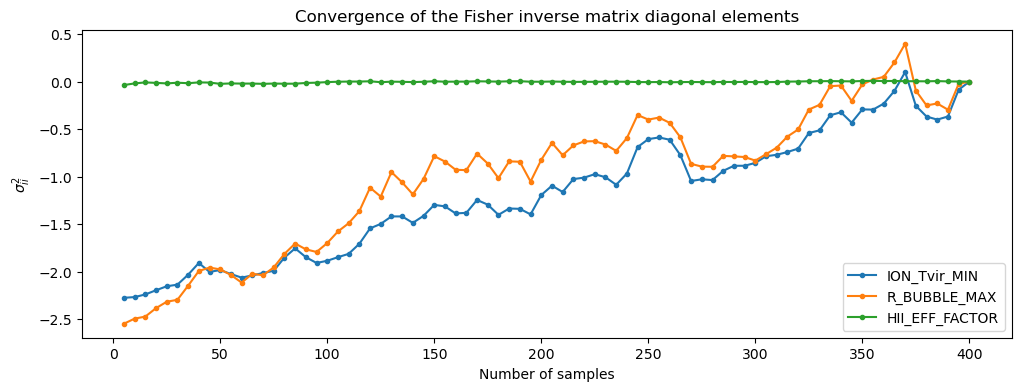

In [12]:

# SKA AA star 1000
plt.figure(figsize=(12, 4))
for i, param in enumerate(params):
    plt.plot(samples, [np.diag(BS_Fisher_Inv_SKA_AA_star_1000[k])[i]-np.diag(BS_Fisher_Inv_SKA_AA_star_1000[-1])[i] for k in range(samples.size)], marker='.', label=param)
plt.legend()
plt.ylabel(r'$\sigma^2_{ii}$')
plt.xlabel('Number of samples')
plt.title('Convergence of the Fisher inverse matrix diagonal elements')


Text(0.5, 1.0, 'Convergence of the Fisher inverse matrix diagonal elements')

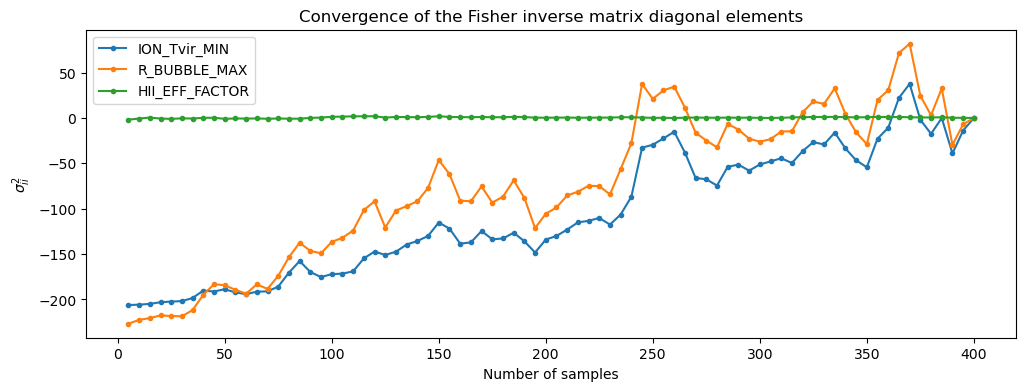

In [13]:

# SKA AA star 100
plt.figure(figsize=(12, 4))
for i, param in enumerate(params):
    plt.plot(samples, [np.diag(BS_Fisher_Inv_SKA_AA_star_100[k])[i]-np.diag(BS_Fisher_Inv_SKA_AA_star_100[-1])[i] for k in range(samples.size)], marker='.', label=param)
plt.legend()
plt.ylabel(r'$\sigma^2_{ii}$')
plt.xlabel('Number of samples')
plt.title('Convergence of the Fisher inverse matrix diagonal elements')

Text(0.5, 1.0, 'Convergence of the Fisher inverse matrix diagonal elements')

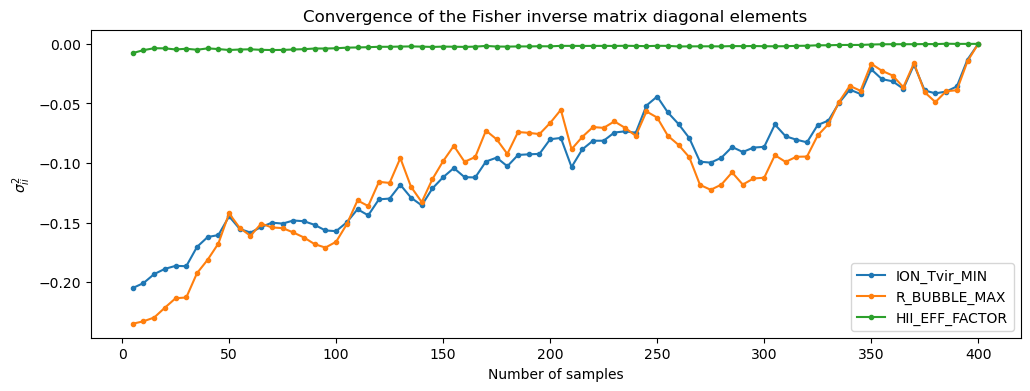

In [14]:

# SKA AA4
plt.figure(figsize=(12, 4))
for i, param in enumerate(params):
    plt.plot(samples, [np.diag(BS_Fisher_Inv_SKA_AA4_1000[k])[i]-np.diag(BS_Fisher_Inv_SKA_AA4_1000[-1])[i] for k in range(samples.size)], marker='.', label=param)
plt.legend()
plt.ylabel(r'$\sigma^2_{ii}$')
plt.xlabel('Number of samples')
plt.title('Convergence of the Fisher inverse matrix diagonal elements')

### Plot and save posterior

In [15]:
fid = [50118.72336272725,15,30]
Fisher_Param = ['$T_{Vir}$','$R_{Max}$','$\zeta$']
fisher_data_SKA_AA_star_1000 = np.random.multivariate_normal(fid, BS_Fisher_Inv_SKA_AA_star_1000[-1], size=50000)
fisher_data_SKA_AA_star_100 = np.random.multivariate_normal(fid, BS_Fisher_Inv_SKA_AA_star_100[-1], size=50000)
fisher_data_SKA_AA4_1000 = np.random.multivariate_normal(fid, BS_Fisher_Inv_SKA_AA4_1000[-1], size=50000)

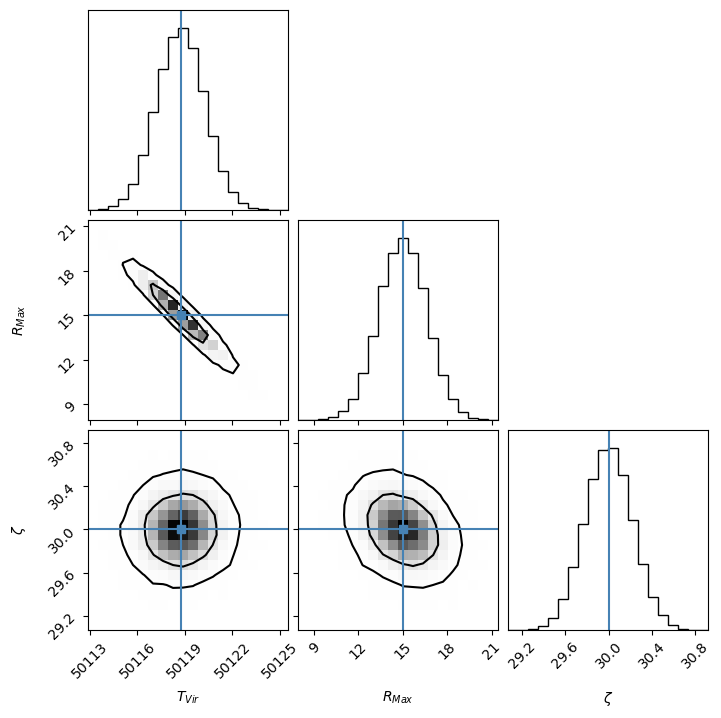

In [16]:
_= corner.corner(
    fisher_data_SKA_AA_star_1000,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,0.95),
    truths=fid)

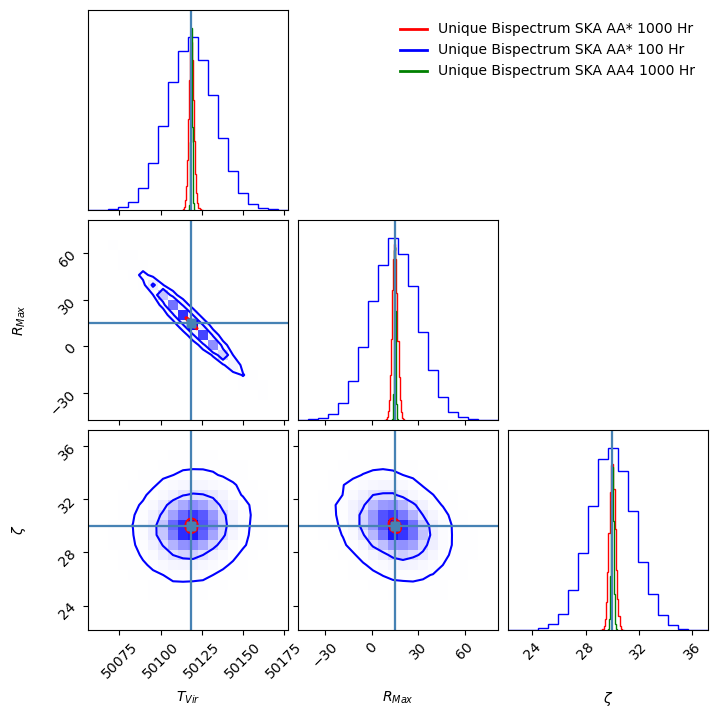

In [17]:

datasets = [fisher_data_SKA_AA_star_1000, fisher_data_SKA_AA_star_100, fisher_data_SKA_AA4_1000]
dataset_labels = ["Unique Bispectrum SKA AA* 1000 Hr", "Unique Bispectrum SKA AA* 100 Hr", "Unique Bispectrum SKA AA4 1000 Hr"]
colors = ["r", "b", "g"]  
labels = Fisher_Param
truths = fid

fig = corner.corner(
    datasets[0],
    labels=labels,
    plot_datapoints=False,
    levels=(0.68, 0.95),
    color=colors[0],
    truths=truths,
)
for i in range(1, len(datasets)):
    corner.corner(
        datasets[i],
        labels=labels,
        plot_datapoints=False,
        levels=(0.68, 0.95),
        color=colors[i],
        truths=truths,
        fig=fig,  
    )

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=colors[i], lw=2, label=dataset_labels[i])
    for i in range(len(datasets))
]

axes = np.array(fig.axes).reshape((len(labels), len(labels)))
ax = axes[0, -1]  
ax.legend(handles=legend_handles, loc='upper right', frameon=False)



In [19]:
np.savetxt("squeezed_BS_Fisher_SKA_AA_star_1000.txt",BS_Fisher_Inv_SKA_AA_star_1000[-1])
np.savetxt("squeezed_BS_Fisher_SKA_AA_star_100.txt",BS_Fisher_Inv_SKA_AA_star_100[-1])
np.savetxt("squeezed_BS_Fisher_SKA_AA4_1000.txt",BS_Fisher_Inv_SKA_AA4_1000[-1])